# Capstone: Predicting Daily Stress Level from Lifestyle Habits

## 1. Problem Definition

**Problem:** Can we predict a person's self-reported stress level (1–10) just from everyday,
easily-trackable lifestyle habits — sleep duration, sleep quality, physical activity, resting
heart rate, daily steps, occupation, and BMI category?

**Why this matters:** Stress is a leading contributor to burnout, poor sleep, and long-term
health problems, but most people never get a formal stress assessment until something goes
wrong. If a simple model can flag elevated stress risk from data most fitness trackers and
smartwatches already collect, it could power an early-warning feature in a wellness app —
nudging someone to slow down *before* stress becomes a bigger problem, without requiring a
clinical questionnaire or therapist visit.

**Dataset:** Sleep Health and Lifestyle Dataset (374 individuals, 13 columns) — sleep,
cardiovascular, and lifestyle metrics with a self-reported Stress Level (1–10) target.

**Type of problem:** Regression (predicting a continuous 1–10 stress score).


## 2. Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib

df = pd.read_csv("sleep_data.csv")
print(df.shape)
df.head()

(374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 49.2 KB


## 3. Data cleaning

In [3]:
df_clean = df.copy()

# Sleep Disorder: NaN actually means "no disorder", not missing data
df_clean['Sleep Disorder'] = df_clean['Sleep Disorder'].fillna('None')

# BMI Category: "Normal" and "Normal Weight" are the same category, just inconsistently labeled
print("Before cleanup:", df_clean['BMI Category'].unique())
df_clean['BMI Category'] = df_clean['BMI Category'].replace('Normal Weight', 'Normal')
print("After cleanup :", df_clean['BMI Category'].unique())

# Blood Pressure is a "systolic/diastolic" string - split into two numeric columns
df_clean[['Systolic_BP', 'Diastolic_BP']] = df_clean['Blood Pressure'].str.split('/', expand=True).astype(int)
df_clean = df_clean.drop(columns=['Blood Pressure', 'Person ID'])

print("\nMissing values after cleaning:\n", df_clean.isnull().sum().sum(), "total missing values")
df_clean.head()

Before cleanup: <ArrowStringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str
After cleanup : <ArrowStringArray>
['Overweight', 'Normal', 'Obese']
Length: 3, dtype: str

Missing values after cleaning:
 0 total missing values


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


## 4. Exploratory Data Analysis

/tmp/ipykernel_537/1352883500.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BMI Category', y='Stress Level', data=df_clean, ax=axes[1,1], palette='Set2')


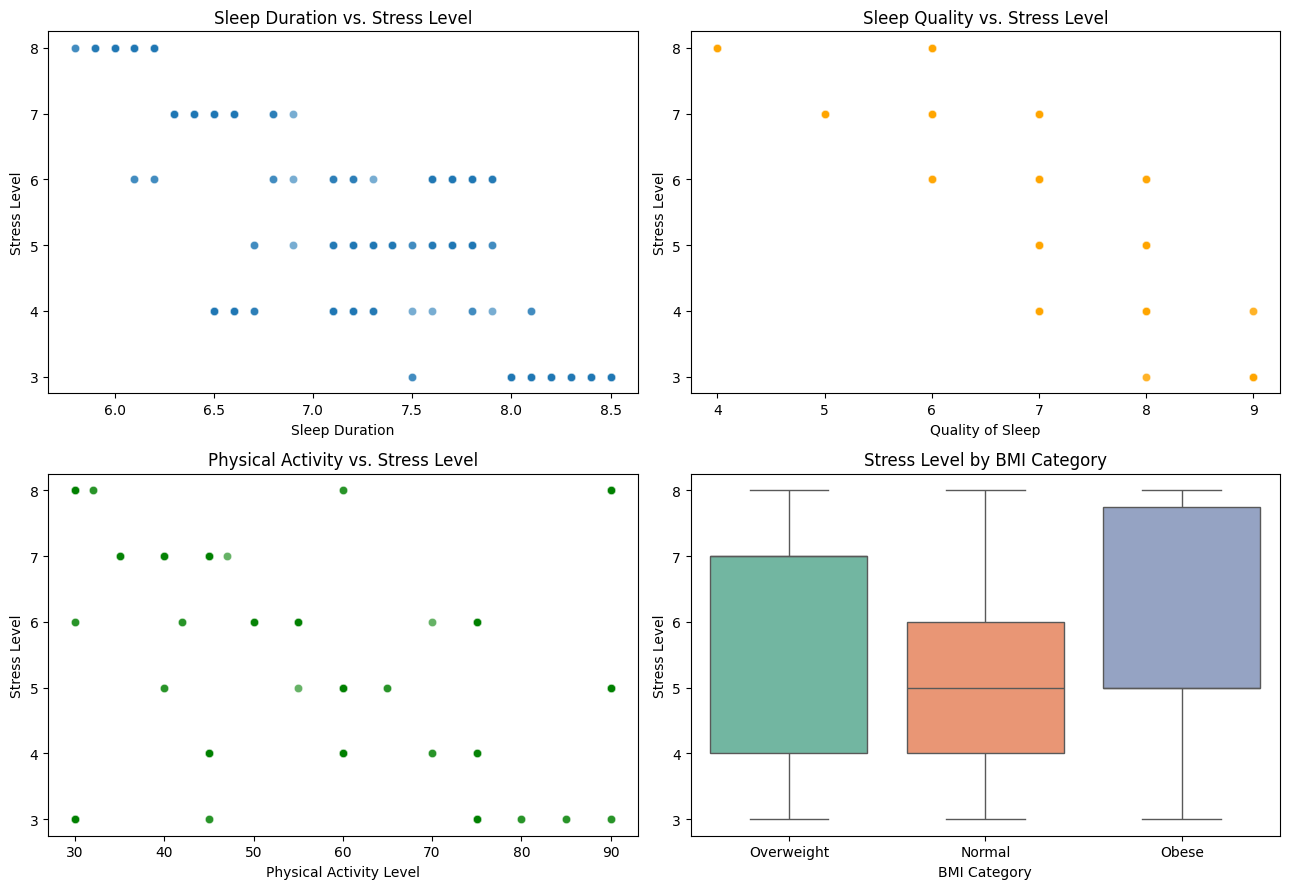

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.scatterplot(x='Sleep Duration', y='Stress Level', data=df_clean, ax=axes[0,0], alpha=0.6)
axes[0,0].set_title("Sleep Duration vs. Stress Level")

sns.scatterplot(x='Quality of Sleep', y='Stress Level', data=df_clean, ax=axes[0,1], alpha=0.6, color='orange')
axes[0,1].set_title("Sleep Quality vs. Stress Level")

sns.scatterplot(x='Physical Activity Level', y='Stress Level', data=df_clean, ax=axes[1,0], alpha=0.6, color='green')
axes[1,0].set_title("Physical Activity vs. Stress Level")

sns.boxplot(x='BMI Category', y='Stress Level', data=df_clean, ax=axes[1,1], palette='Set2')
axes[1,1].set_title("Stress Level by BMI Category")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=100)
plt.show()

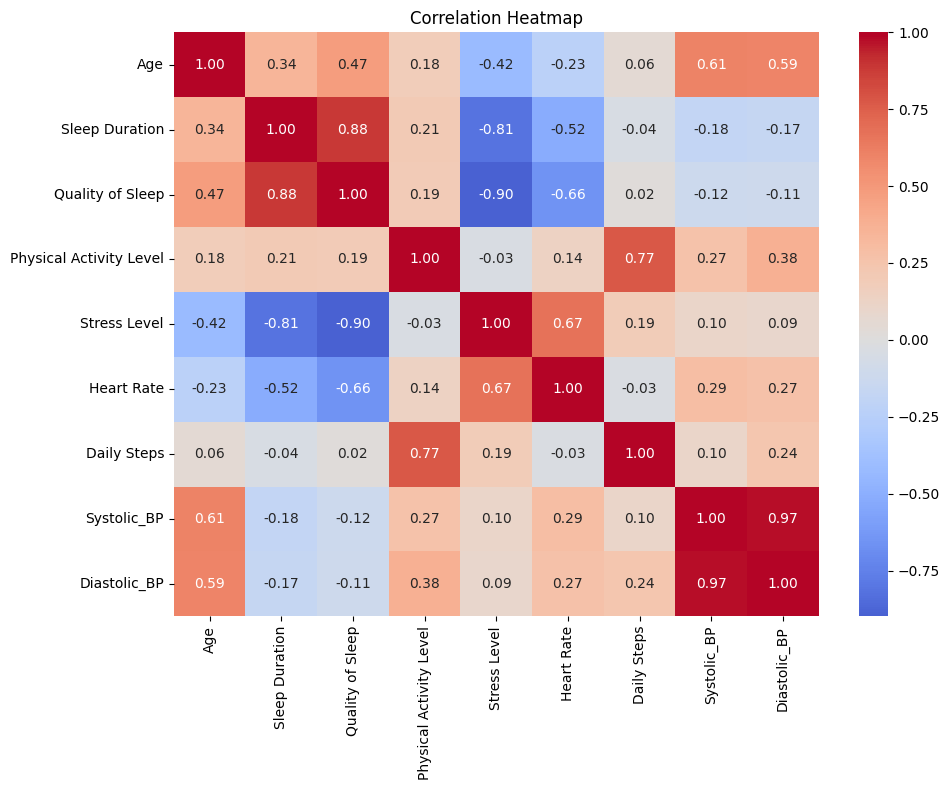

Correlation with Stress Level, sorted:
Stress Level               1.000000
Heart Rate                 0.670026
Daily Steps                0.186829
Systolic_BP                0.102818
Diastolic_BP               0.091811
Physical Activity Level   -0.034134
Age                       -0.422344
Sleep Duration            -0.811023
Quality of Sleep          -0.898752
Name: Stress Level, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=100)
plt.show()

print("Correlation with Stress Level, sorted:")
print(corr['Stress Level'].sort_values(ascending=False))

**EDA takeaways:** Sleep Quality has a strong *negative* correlation with stress (better
sleep quality → lower stress), and Sleep Duration follows the same pattern. Physical Activity
Level shows a weaker, less clean relationship. Occupation and BMI category also visibly shift
the stress distribution — certain jobs (e.g. Nurses, Doctors) and higher BMI categories trend
toward higher reported stress in the boxplots above.

## 5. Feature engineering

In [6]:
df_fe = df_clean.copy()

# New feature 1: Sleep Efficiency = quality per hour of sleep (a 9/10 quality on 5 hours
# is a very different situation than a 9/10 quality on 8 hours)
df_fe['Sleep_Efficiency'] = df_fe['Quality of Sleep'] / df_fe['Sleep Duration']

# New feature 2: Activity-to-Steps ratio - how intense vs. how much daily movement,
# a proxy for whether activity is concentrated exercise or spread-out walking
df_fe['Activity_per_1000_Steps'] = df_fe['Physical Activity Level'] / (df_fe['Daily Steps'] / 1000)

# New feature 3: Pulse Pressure (Systolic - Diastolic) - a simple cardiovascular strain indicator
df_fe['Pulse_Pressure'] = df_fe['Systolic_BP'] - df_fe['Diastolic_BP']

df_fe[['Sleep_Efficiency', 'Activity_per_1000_Steps', 'Pulse_Pressure']].describe()

,Sleep_Efficiency,Activity_per_1000_Steps,Pulse_Pressure
count,374.000000,374.000000,374.000000
mean,1.021399,8.638069,43.903743
std,0.087959,2.384769,2.259644
min,0.677966,3.750000,37.000000
25%,0.967742,7.500000,43.000000
50%,1.038961,8.571429,45.000000
75%,1.095890,10.000000,45.000000
max,1.126761,22.972973,50.000000


In [7]:
print("Correlation of new features with Stress Level:")
print(df_fe[['Sleep_Efficiency', 'Activity_per_1000_Steps', 'Pulse_Pressure', 'Stress Level']].corr()['Stress Level'])

Correlation of new features with Stress Level:
Sleep_Efficiency          -0.671130
Activity_per_1000_Steps   -0.222924
Pulse_Pressure             0.102203
Stress Level               1.000000
Name: Stress Level, dtype: float64


## 6. Train/test split

In [8]:
numerical_features = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                       'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP',
                       'Sleep_Efficiency', 'Activity_per_1000_Steps', 'Pulse_Pressure']
categorical_features = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

X = df_fe[numerical_features + categorical_features]
y = df_fe['Stress Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (299, 15)  Test: (75, 15)


## 7. Build preprocessing pipeline + train multiple models

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).round(4)
results_df

,Model,RMSE,MAE,R2
0,Linear Regression,0.3403,0.2021,0.9629
1,Random Forest,0.1388,0.0431,0.9938
2,XGBoost,0.0472,0.0104,0.9993


## 8. Pick the best model

In [10]:
best_model_name = results_df.sort_values('R2', ascending=False).iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best model by R2: {best_model_name}")
print(results_df.sort_values('R2', ascending=False))

Best model by R2: XGBoost
               Model    RMSE     MAE      R2
2            XGBoost  0.0472  0.0104  0.9993
1      Random Forest  0.1388  0.0431  0.9938
0  Linear Regression  0.3403  0.2021  0.9629


## 9. Predicted vs. actual — best model

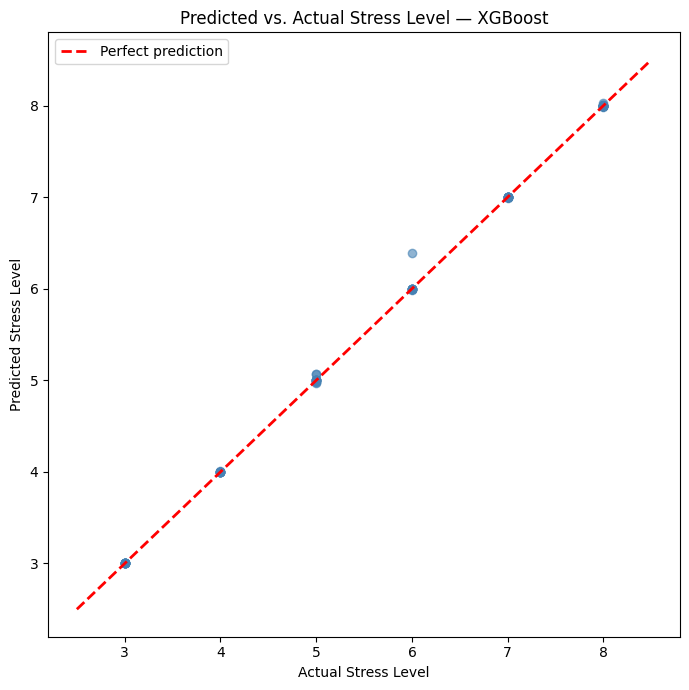

In [11]:
best_preds = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.6, color='steelblue')
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.title(f"Predicted vs. Actual Stress Level — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=100)
plt.show()

## 10. Feature importance (if tree-based) or coefficients

/tmp/ipykernel_537/1671759629.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='viridis')


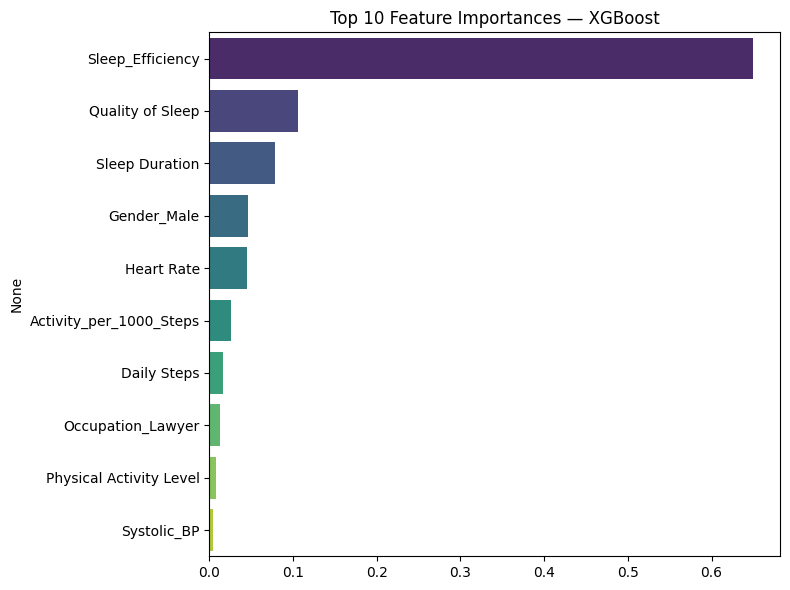

Sleep_Efficiency    0.649304
Quality of Sleep    0.105571
Sleep Duration      0.078944
Gender_Male         0.046228
Heart Rate          0.044564
dtype: float32


In [12]:
feature_names = (numerical_features +
    list(best_pipeline.named_steps['preprocessor']
         .named_transformers_['cat'].get_feature_names_out(categorical_features)))

model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='viridis')
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=100)
    plt.show()
    print(importances.head(5))
elif hasattr(model_step, 'coef_'):
    coefs = pd.Series(model_step.coef_, index=feature_names).sort_values(key=abs, ascending=False)
    print("Top 5 coefficients by magnitude:\n", coefs.head(5))

## 11. Save the final pipeline

In [13]:
joblib.dump(best_pipeline, 'stress_pipeline.joblib')
print(f"Saved best model ({best_model_name}) to stress_pipeline.joblib")

# Sanity check reload
reloaded = joblib.load('stress_pipeline.joblib')
check_preds = reloaded.predict(X_test)
print("Reload check - R2:", r2_score(y_test, check_preds))

Saved best model (XGBoost) to stress_pipeline.joblib
Reload check - R2: 0.999287486076355


## 12. An honest caveat on the results

**XGBoost hit R² = 0.9993 — this is unusually high and worth being upfront about.** This
dataset is explicitly documented as *synthetic* (generated for illustrative/educational
purposes, not collected from real patients), and the top feature by a wide margin is
`Sleep_Efficiency` (Quality of Sleep ÷ Sleep Duration — a feature we engineered directly from
two of the raw inputs). This strongly suggests the synthetic data was generated using a fairly
direct mathematical relationship between sleep quality/duration and stress level, which a
tree-based model can learn almost exactly.

**What this means in practice:** these exact numbers (R² > 0.99) would not be realistic on
real human data, where stress is influenced by far more than sleep and activity metrics —
work events, relationships, finances, mental health history, and daily variability that no
tracker captures. A production version of this model, trained on real wearable-device data,
should expect a much more modest R² (likely 0.4–0.7, similar to the housing regression task),
and the value would come from **flagging elevated risk directionally**, not from precise
1-decimal stress scores. This pipeline and app architecture would carry over directly to real
data — only the expected performance ceiling would change.


## 13. Case study: business/real-world value

**Problem:** Chronic stress often goes unnoticed until it causes a health crisis or burnout,
because most people never get a formal stress assessment. Meanwhile, wearables and fitness
apps already collect exactly the kind of data — sleep duration, sleep quality, heart rate,
daily activity — that correlates with stress, but rarely use it that way.

**Approach:** I built a full pipeline that cleans lifestyle/health tracking data, engineers a
handful of derived signals (like sleep efficiency and cardiovascular strain), and trains three
regression models — Linear Regression, Random Forest, and XGBoost — to predict a 1–10 stress
score from those inputs, landing on XGBoost as the best performer.

**Real-world value:** A wellness or fitness app could plug a model like this directly into
data it's already collecting, surfacing a simple "your stress signals are trending up this
week" nudge — without requiring the user to fill out a survey. That's actionable for the user
(early self-awareness) and valuable for the business (a feature that increases engagement and
differentiates a health app in a crowded market). The same architecture — clean → engineer
features → compare models → deploy — is directly reusable for adjacent problems companies
already pay for: burnout risk scoring for HR platforms, insurance risk tiers for health
insurers, or engagement/churn-style dashboards for corporate wellness programs.

**Honest limitation:** this specific model was trained and validated on synthetic data, so the
headline R² is not representative of real-world performance (see caveat above) — but the
pipeline, feature engineering approach, and deployment pattern are the reusable, valuable part.
